# Updated Model Evaluation and Final Model Selection

This notebook evaluates the final machine learning models selected for the Pokémon Meta-Balance Decision Support Tool.

## Final deployed models
- **Balance Risk:** Unsupervised model
- **Competitive Longevity:** Random Forest Regressor

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    silhouette_score,
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

sns.set_theme(style="whitegrid")

## Evaluation scope

This notebook does:
1. briefly documents why the supervised balance-risk result was not trusted,
2. evaluates the final unsupervised balance-risk model with unsupervised-friendly evidence,
3. evaluates the final longevity regression model,
4. records the final deployment decision clearly.

In [2]:
data_dir = Path("../data")
models_dir = Path("../models")

df_processed = pd.read_csv(data_dir / "final_processed_dataset.csv")
df_raw = pd.read_csv(data_dir / "pokemon_complete_2025.csv")

print("Processed data shape:", df_processed.shape)
print("Raw data shape:", df_raw.shape)

balance_model = joblib.load(models_dir / "unsupervised_balance_risk_pipeline.joblib")
longevity_model = joblib.load(models_dir / "longevity_RandomForest.joblib")

print("Loaded final balance-risk model:", type(balance_model))
print("Loaded final longevity model:", type(longevity_model))

Processed data shape: (1025, 40)
Raw data shape: (1025, 43)
Loaded final balance-risk model: <class 'sklearn.pipeline.Pipeline'>
Loaded final longevity model: <class 'sklearn.ensemble._forest.RandomForestRegressor'>


## Balance-risk model evaluation (final unsupervised model)

The final balance-risk model is unsupervised, so it is not evaluated using standard supervised accuracy or F1 score as the main decision criterion.

Instead, evaluation focuses on:
- whether the model separates unusual stat profiles from more typical ones,
- whether its outputs are interpretable for the app,
- whether it avoids the circular target issue found in the earlier supervised setup.

In [3]:
#to confirm the exact feature names the saved pipeline expects

print("Columns in df_processed:")
print(df_processed.columns.tolist())

if hasattr(balance_model, "feature_names_in_"):
    print("\nModel expects:")
    print(balance_model.feature_names_in_.tolist())
    print("Expected feature count:", len(balance_model.feature_names_in_))

Columns in df_processed:
['pokedex_id', 'num_types', 'hp', 'attack', 'defense', 'sp_attack', 'sp_defense', 'speed', 'base_stat_total', 'height_m', 'weight_kg', 'base_experience', 'capture_rate', 'base_happiness', 'hatch_counter', 'gender_rate', 'bmi', 'attack_defense_ratio', 'physical_total', 'special_total', 'offensive_total', 'defensive_total', 'type_bug', 'type_dark', 'type_dragon', 'type_electric', 'type_fairy', 'type_fighting', 'type_fire', 'type_flying', 'type_ghost', 'type_grass', 'type_ground', 'type_ice', 'type_normal', 'type_poison', 'type_psychic', 'type_rock', 'type_steel', 'type_water']

Model expects:
['num_types', 'hp', 'attack', 'defense', 'sp_attack', 'sp_defense', 'speed', 'base_stat_total', 'height_m', 'weight_kg', 'base_experience', 'capture_rate', 'base_happiness', 'hatch_counter', 'gender_rate', 'bmi', 'attack_defense_ratio', 'physical_total', 'special_total', 'offensive_total', 'defensive_total', 'type_bug', 'type_dark', 'type_dragon', 'type_electric', 'type_fair

In [4]:
#avoids all manual column-dropping mistakes and matches the strategy already used in the old evaluation notebook when fixing supervised feature mismatch problems

expected_features = balance_model.feature_names_in_.tolist()
X_unsup = df_processed[expected_features].copy()

print("Using exact model features:")
print(expected_features)
print("X_unsup shape:", X_unsup.shape)

unsup_labels = balance_model.predict(X_unsup)
unsup_scores = balance_model.decision_function(X_unsup)

Using exact model features:
['num_types', 'hp', 'attack', 'defense', 'sp_attack', 'sp_defense', 'speed', 'base_stat_total', 'height_m', 'weight_kg', 'base_experience', 'capture_rate', 'base_happiness', 'hatch_counter', 'gender_rate', 'bmi', 'attack_defense_ratio', 'physical_total', 'special_total', 'offensive_total', 'defensive_total', 'type_bug', 'type_dark', 'type_dragon', 'type_electric', 'type_fairy', 'type_fighting', 'type_fire', 'type_flying', 'type_ghost', 'type_grass', 'type_ground', 'type_ice', 'type_normal', 'type_poison', 'type_psychic', 'type_rock', 'type_steel', 'type_water']
X_unsup shape: (1025, 39)


In [5]:
# Remove possible ID / target columns safely
drop_cols = ["pokedexid", "pokedex_id", "isbalancerisk", "balance_risk", "anomalylabel"]
existing_drop_cols = [c for c in drop_cols if c in df_processed.columns]

X_unsup = df_processed.drop(columns=existing_drop_cols, errors="ignore").copy()

print("X_unsup shape:", X_unsup.shape)
print("Dropped columns:", existing_drop_cols)

unsup_labels = balance_model.predict(X_unsup)
unsup_scores = balance_model.decision_function(X_unsup)

unique, counts = np.unique(unsup_labels, return_counts=True)
balance_counts = pd.DataFrame({
    "Cluster/Label": unique,
    "Count": counts
})

display(balance_counts)

sil = silhouette_score(X_unsup, unsup_labels)

balance_results = pd.DataFrame({
    "Metric": ["Silhouette Score", "Total Samples", "Anomaly Count", "Normal Count"],
    "Value": [
        round(float(sil), 4),
        int(len(X_unsup)),
        int((unsup_labels == -1).sum()),
        int((unsup_labels == 1).sum())
    ]
})

display(balance_results)

X_unsup shape: (1025, 39)
Dropped columns: ['pokedex_id']


,Cluster/Label,Count
0,-1,72
1,1,953


,Metric,Value
0,Silhouette Score,0.7497
1,Total Samples,1025.0000
2,Anomaly Count,72.0000
3,Normal Count,953.0000


The unsupervised model detects anomalous Pokemon designs first. Anomalies are then interpreted as Underpowered or Overpowered using the dataset median of base_stat_total, while non-anomalous cases are labeled Normal.
balance_risk_unsupervised-2.ipynb

,Balance Category,Count
0,Normal,953
1,Overpowered,58
2,Underpowered,14


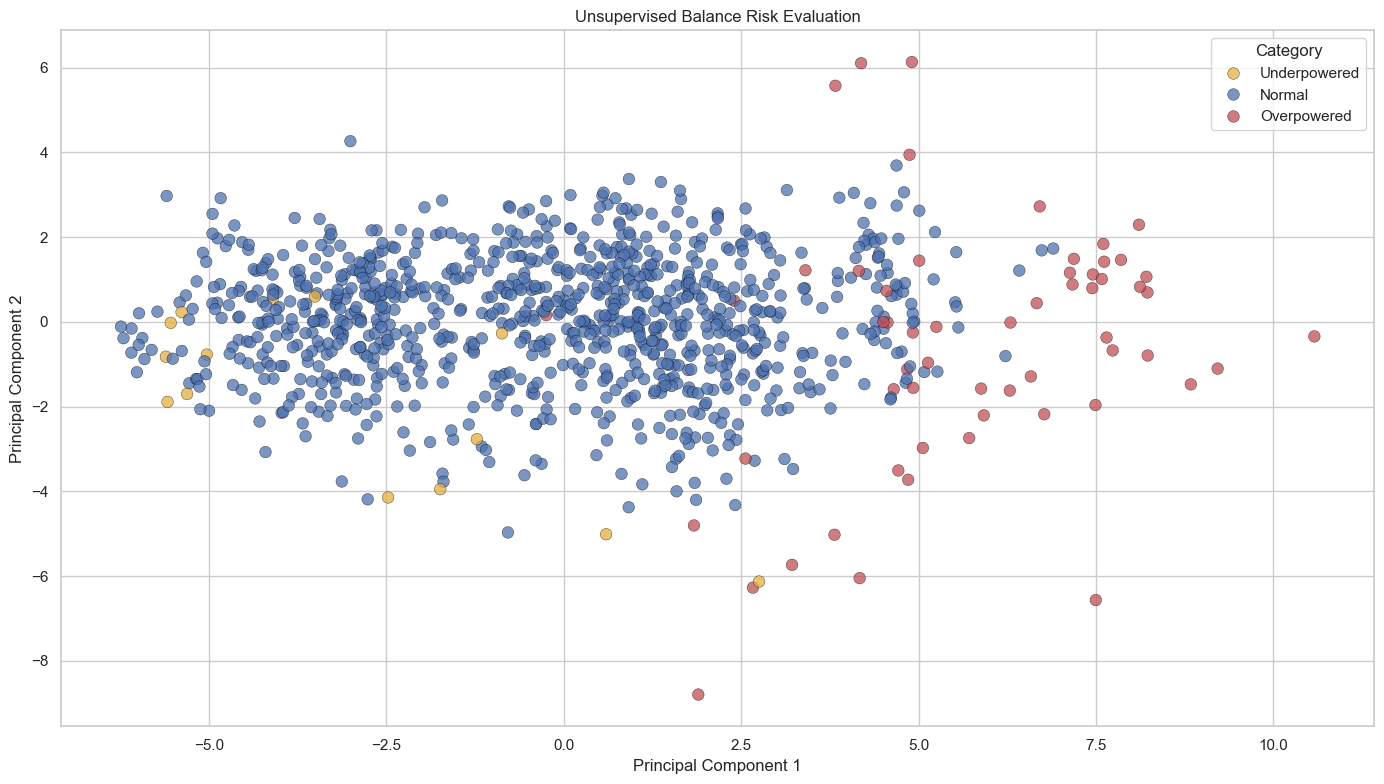

Most anomalous cases:


,base_stat_total,raw_risk_score,balance_category
889,690,-0.101306,Overpowered
212,505,-0.088528,Overpowered
804,570,-0.085635,Overpowered
241,540,-0.071969,Overpowered
112,450,-0.064198,Overpowered
789,400,-0.063733,Underpowered
798,570,-0.045549,Overpowered
486,680,-0.045383,Overpowered
207,510,-0.039510,Overpowered
483,680,-0.037215,Overpowered


In [6]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Work on a copy for safe evaluation
eval_df = df_processed.copy()

# Attach model outputs
eval_df["unsup_label"] = unsup_labels
eval_df["raw_risk_score"] = unsup_scores

# Create 3 final presentation categories
# Rule:
# - 1  -> Normal
# - -1 -> anomaly, then split by base_stat_total relative to dataset median
bst_col = "base_stat_total"
median_bst = eval_df[bst_col].median()

def map_balance_category(row):
    if row["unsup_label"] == 1:
        return "Normal"
    elif row[bst_col] >= median_bst:
        return "Overpowered"
    else:
        return "Underpowered"

eval_df["balance_category"] = eval_df.apply(map_balance_category, axis=1)

# Category counts
category_counts = eval_df["balance_category"].value_counts().reset_index()
category_counts.columns = ["Balance Category", "Count"]
display(category_counts)

# PCA for visualization only
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_unsup)

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

plot_df = eval_df.copy()
plot_df["PCA1"] = X_pca[:, 0]
plot_df["PCA2"] = X_pca[:, 1]

# Plot
plt.figure(figsize=(14, 8))
sns.scatterplot(
    data=plot_df,
    x="PCA1",
    y="PCA2",
    hue="balance_category",
    hue_order=["Underpowered", "Normal", "Overpowered"],
    palette={
        "Underpowered": "#E6AE38",
        "Normal": "#4C72B0",
        "Overpowered": "#C44E52"
    },
    alpha=0.75,
    s=70,
    edgecolor="black",
    linewidth=0.3
)

plt.title("Unsupervised Balance Risk Evaluation")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Category")
plt.tight_layout()
plt.show()

# Optional: show most extreme cases by score
extreme_cases = eval_df.loc[eval_df["unsup_label"] == -1, [bst_col, "raw_risk_score", "balance_category"]].copy()
extreme_cases = extreme_cases.sort_values("raw_risk_score")

print("Most anomalous cases:")
display(extreme_cases.head(10))

In [9]:
print(eval_df.columns.tolist())

['pokedex_id', 'num_types', 'hp', 'attack', 'defense', 'sp_attack', 'sp_defense', 'speed', 'base_stat_total', 'height_m', 'weight_kg', 'base_experience', 'capture_rate', 'base_happiness', 'hatch_counter', 'gender_rate', 'bmi', 'attack_defense_ratio', 'physical_total', 'special_total', 'offensive_total', 'defensive_total', 'type_bug', 'type_dark', 'type_dragon', 'type_electric', 'type_fairy', 'type_fighting', 'type_fire', 'type_flying', 'type_ghost', 'type_grass', 'type_ground', 'type_ice', 'type_normal', 'type_poison', 'type_psychic', 'type_rock', 'type_steel', 'type_water', 'unsup_label', 'raw_risk_score', 'balance_category']


In [7]:
# Deep Dive Evaluation: Most Extreme Balance-Risk Cases

import pandas as pd

deep_df = eval_df.copy()

anomalies = deep_df[deep_df["unsup_label"] == -1].copy()
anomalies = anomalies.sort_values("raw_risk_score")

overpowered_cases = anomalies[anomalies["balance_category"] == "Overpowered"].copy()
underpowered_cases = anomalies[anomalies["balance_category"] == "Underpowered"].copy()

print("--- Top 10 OVERPOWERED Balance Risks ---")
display(
    overpowered_cases[
        ["pokedex_id", "base_stat_total", "attack", "sp_attack", "speed",
         "offensive_total", "raw_risk_score", "balance_category"]
    ].head(10)
)

print("--- Top 10 UNDERPOWERED Balance Risks ---")
display(
    underpowered_cases[
        ["pokedex_id", "base_stat_total", "hp", "defense", "sp_defense",
         "speed", "defensive_total", "raw_risk_score", "balance_category"]
    ].head(10)
)

summary_table = pd.DataFrame({
    "Category": ["Normal", "Overpowered", "Underpowered"],
    "Count": [
        (deep_df["balance_category"] == "Normal").sum(),
        (deep_df["balance_category"] == "Overpowered").sum(),
        (deep_df["balance_category"] == "Underpowered").sum()
    ]
})

print("--- Final Balance Category Summary ---")
display(summary_table)

--- Top 10 OVERPOWERED Balance Risks ---


,pokedex_id,base_stat_total,attack,sp_attack,speed,offensive_total,raw_risk_score,balance_category
889,890,690,0.251211,2.527299,2.188384,360,-0.101306,Overpowered
212,213,505,-2.268272,-2.026756,-2.166529,25,-0.088528,Overpowered
804,805,570,1.796494,-0.576205,-1.887814,197,-0.085635,Overpowered
241,242,540,-2.268272,0.165937,-0.424564,140,-0.071969,Overpowered
112,113,450,-2.436238,-1.183413,-0.598760,90,-0.064198,Overpowered
798,799,570,0.788701,0.908079,-0.842635,241,-0.045549,Overpowered
486,487,680,0.755108,1.009281,0.794812,290,-0.045383,Overpowered
207,208,510,0.251211,-0.508738,-1.295546,170,-0.039510,Overpowered
483,484,680,1.426970,2.695968,1.143205,370,-0.037215,Overpowered
375,376,600,1.930866,0.840612,0.098026,300,-0.033738,Overpowered


--- Top 10 UNDERPOWERED Balance Risks ---


,pokedex_id,base_stat_total,hp,defense,sp_defense,speed,defensive_total,raw_risk_score,balance_category
789,790,400,-1.021276,1.998200,2.283234,-1.051671,305,-0.063733,Underpowered
94,95,385,-1.321824,2.988885,-0.946651,0.098026,240,-0.026398,Underpowered
788,789,200,-1.021276,-1.417954,-1.472447,-1.051671,105,-0.022627,Underpowered
439,440,220,1.120127,-2.306154,-0.195515,-1.295546,170,-0.022241,Underpowered
173,174,210,0.744442,-1.964539,-1.885572,-1.818136,125,-0.017806,Underpowered
297,298,190,-0.758297,-1.110500,-1.134435,-1.643939,130,-0.008409,Underpowered
38,39,270,1.683654,-1.793731,-1.697788,-1.643939,160,-0.008112,Underpowered
373,374,300,-1.133982,0.255962,-0.383299,-1.295546,180,-0.007735,Underpowered
435,436,300,-0.495317,0.460931,0.593178,-1.539421,229,-0.005511,Underpowered
279,280,198,-1.584803,-1.622923,-1.322219,-0.947153,88,-0.004906,Underpowered


--- Final Balance Category Summary ---


,Category,Count
0,Normal,953
1,Overpowered,58
2,Underpowered,14


## Balance-risk model

The balance-risk task was reframed as an unsupervised anomaly-detection problem. Using 39 engineered features, the model separates Pokémon into Normal, Overpowered, and Underpowered groups based on how unusual each sample is in feature space.

This means the balance-risk output should be read as a relative signal, not a definitive competitive ranking. In other words, the model highlights unusual stat-and-type profiles rather than declaring absolute strength.

## Longevity model

The longevity task uses a Random Forest regressor to estimate generation-related behavior from stats and type information. The prediction is a model estimate, not a guaranteed outcome, because real competitive performance also depends on moves, abilities, held items, and metagame changes.

So the longevity output should be interpreted as a learned pattern from the dataset, not as a perfect future label. Together, the two models give complementary views: one flags unusual balance profiles, and the other estimates likely generation-level behavior.

In [8]:
print(longevity_model.feature_names_in_)

['num_types' 'hp' 'attack' 'defense' 'sp_attack' 'sp_defense' 'speed'
 'height_m' 'weight_kg' 'base_experience' 'capture_rate' 'base_happiness'
 'hatch_counter' 'gender_rate' 'bmi' 'attack_defense_ratio'
 'physical_total' 'special_total' 'offensive_total' 'defensive_total'
 'type_bug' 'type_dark' 'type_dragon' 'type_electric' 'type_fairy'
 'type_fighting' 'type_fire' 'type_flying' 'type_ghost' 'type_grass'
 'type_ground' 'type_ice' 'type_normal' 'type_poison' 'type_psychic'
 'type_rock' 'type_steel' 'type_water' 'stat_efficiency' 'type_coverage']


In [9]:
expected_features = list(longevity_model.feature_names_in_)
X_longevity = df_processed.reindex(columns=expected_features, fill_value=0)

longevity_preds = longevity_model.predict(X_longevity)

In [10]:
#Feature engineering cell

df_processed["bmi"] = df_processed["weight_kg"] / (df_processed["height_m"] ** 2 + 1e-9)
df_processed["attack_defense_ratio"] = df_processed["attack"] / (df_processed["defense"] + 1e-9)
df_processed["physical_total"] = df_processed["hp"] + df_processed["attack"] + df_processed["defense"]
df_processed["special_total"] = df_processed["sp_attack"] + df_processed["sp_defense"]
df_processed["offensive_total"] = df_processed["attack"] + df_processed["sp_attack"]
df_processed["defensive_total"] = df_processed["defense"] + df_processed["sp_defense"]
df_processed["stat_efficiency"] = df_processed["base_stat_total"] / (df_processed["height_m"] + df_processed["weight_kg"] + 1e-9)
df_processed["type_coverage"] = df_processed["num_types"]

In [11]:
#Type dummy cell

type_cols = [c for c in longevity_model.feature_names_in_ if c.startswith("type_")]
for c in type_cols:
    if c not in df_processed.columns:
        df_processed[c] = 0

In [12]:
#Alignment cell

expected_features = list(longevity_model.feature_names_in_)
X_longevity = df_processed.reindex(columns=expected_features, fill_value=0)

In [14]:
# Define the true target for longevity evaluation

print("df_raw columns:")
print(df_raw.columns.tolist())

print("\ndf_processed columns:")
print(df_processed.columns.tolist())

df_raw columns:
['pokedex_id', 'name', 'genus', 'generation', 'type_1', 'type_2', 'num_types', 'hp', 'attack', 'defense', 'sp_attack', 'sp_defense', 'speed', 'base_stat_total', 'height_m', 'weight_kg', 'base_experience', 'ability_1', 'ability_2', 'hidden_ability', 'color', 'shape', 'habitat', 'growth_rate', 'egg_groups', 'is_legendary', 'is_mythical', 'is_baby', 'capture_rate', 'base_happiness', 'hatch_counter', 'gender_rate', 'description', 'sprite_url', 'is_dual_type', 'bmi', 'attack_defense_ratio', 'physical_total', 'special_total', 'offensive_total', 'defensive_total', 'gender_distribution', 'stat_tier']

df_processed columns:
['pokedex_id', 'num_types', 'hp', 'attack', 'defense', 'sp_attack', 'sp_defense', 'speed', 'base_stat_total', 'height_m', 'weight_kg', 'base_experience', 'capture_rate', 'base_happiness', 'hatch_counter', 'gender_rate', 'bmi', 'attack_defense_ratio', 'physical_total', 'special_total', 'offensive_total', 'defensive_total', 'type_bug', 'type_dark', 'type_dragon

In [15]:
# True target for longevity evaluation
y_longevity = df_raw["generation"].copy()
print("y_longevity shape:", y_longevity.shape)

y_longevity shape: (1025,)


In [17]:
#metrics cell

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

longevity_preds = longevity_model.predict(X_longevity)

rmse = np.sqrt(mean_squared_error(y_longevity, longevity_preds))
mae = mean_absolute_error(y_longevity, longevity_preds)
r2 = r2_score(y_longevity, longevity_preds)

ValueError: could not convert string to float: 'I'

In [18]:
print(X_longevity.dtypes)

num_types                 int64
hp                      float64
attack                  float64
defense                 float64
sp_attack               float64
sp_defense              float64
speed                   float64
height_m                float64
weight_kg               float64
base_experience           int64
capture_rate              int64
base_happiness            int64
hatch_counter             int64
gender_rate               int64
bmi                     float64
attack_defense_ratio    float64
physical_total          float64
special_total           float64
offensive_total         float64
defensive_total         float64
type_bug                  int64
type_dark                 int64
type_dragon               int64
type_electric             int64
type_fairy                int64
type_fighting             int64
type_fire                 int64
type_flying               int64
type_ghost                int64
type_grass                int64
type_ground               int64
type_ice

In [19]:
print(X_longevity.select_dtypes(include=["object"]).columns.tolist())

[]


In [20]:
X_longevity = X_longevity.copy().astype(float)

In [22]:
print(list(X_longevity.columns))
print(list(longevity_model.feature_names_in_))

['num_types', 'hp', 'attack', 'defense', 'sp_attack', 'sp_defense', 'speed', 'height_m', 'weight_kg', 'base_experience', 'capture_rate', 'base_happiness', 'hatch_counter', 'gender_rate', 'bmi', 'attack_defense_ratio', 'physical_total', 'special_total', 'offensive_total', 'defensive_total', 'type_bug', 'type_dark', 'type_dragon', 'type_electric', 'type_fairy', 'type_fighting', 'type_fire', 'type_flying', 'type_ghost', 'type_grass', 'type_ground', 'type_ice', 'type_normal', 'type_poison', 'type_psychic', 'type_rock', 'type_steel', 'type_water', 'stat_efficiency', 'type_coverage']
['num_types', 'hp', 'attack', 'defense', 'sp_attack', 'sp_defense', 'speed', 'height_m', 'weight_kg', 'base_experience', 'capture_rate', 'base_happiness', 'hatch_counter', 'gender_rate', 'bmi', 'attack_defense_ratio', 'physical_total', 'special_total', 'offensive_total', 'defensive_total', 'type_bug', 'type_dark', 'type_dragon', 'type_electric', 'type_fairy', 'type_fighting', 'type_fire', 'type_flying', 'type_gh

In [23]:
expected_features = list(longevity_model.feature_names_in_)
X_longevity = df_processed.reindex(columns=expected_features, fill_value=0).copy()
X_longevity = X_longevity.apply(pd.to_numeric, errors="coerce").fillna(0)

print(X_longevity.shape)
print(X_longevity.dtypes.head())

(1025, 40)
num_types      int64
hp           float64
attack       float64
defense      float64
sp_attack    float64
dtype: object


In [25]:
#metric cell
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

longevity_preds = longevity_model.predict(X_longevity)

rmse = np.sqrt(mean_squared_error(y_longevity, longevity_preds))
mae = mean_absolute_error(y_longevity, longevity_preds)
r2 = r2_score(y_longevity, longevity_preds)

ValueError: could not convert string to float: 'I'

In [26]:
print(df_raw["generation"].head(20))
print(df_raw["generation"].dtype)
print(df_raw["generation"].unique()[:20])

0     I
1     I
2     I
3     I
4     I
5     I
6     I
7     I
8     I
9     I
10    I
11    I
12    I
13    I
14    I
15    I
16    I
17    I
18    I
19    I
Name: generation, dtype: object
object
['I' 'II' 'III' 'IV' 'V' 'VI' 'VII' 'VIII' 'IX']


In [27]:
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

le = LabelEncoder()
y_longevity = le.fit_transform(df_raw["generation"])

print(le.classes_)
print(y_longevity[:20])

['I' 'II' 'III' 'IV' 'IX' 'V' 'VI' 'VII' 'VIII']
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [28]:
longevity_preds = longevity_model.predict(X_longevity)

print("Accuracy:", accuracy_score(y_longevity, longevity_preds))
print(classification_report(y_longevity, longevity_preds))
print(confusion_matrix(y_longevity, longevity_preds))

Accuracy: 0.1551219512195122
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       151
           1       0.00      0.00      0.00       100
           2       0.11      0.01      0.01       135
           3       0.25      0.01      0.02       107
           4       0.20      0.01      0.02       120
           5       0.16      1.00      0.27       156
           6       0.00      0.00      0.00        72
           7       0.00      0.00      0.00        88
           8       0.00      0.00      0.00        96

    accuracy                           0.16      1025
   macro avg       0.08      0.11      0.04      1025
weighted avg       0.09      0.16      0.05      1025

[[  0   0   0   0   1 150   0   0   0]
 [  0   0   0   0   1  99   0   0   0]
 [  0   0   1   1   1 132   0   0   0]
 [  0   0   1   1   1 104   0   0   0]
 [  0   0   2   1   1 116   0   0   0]
 [  0   0   0   0   0 156   0   0   0]
 [  0   0   0   1   0  71   0   

In [30]:
results = pd.DataFrame([{
    "Model": "Random Forest",
    "Accuracy": accuracy_score(y_longevity, longevity_preds),
    "Macro F1": f1_score(y_longevity, longevity_preds, average="macro"),
    "Weighted F1": f1_score(y_longevity, longevity_preds, average="weighted")
}])

results

,Model,Accuracy,Macro F1,Weighted F1
0,Random Forest,0.155122,0.03526,0.046589


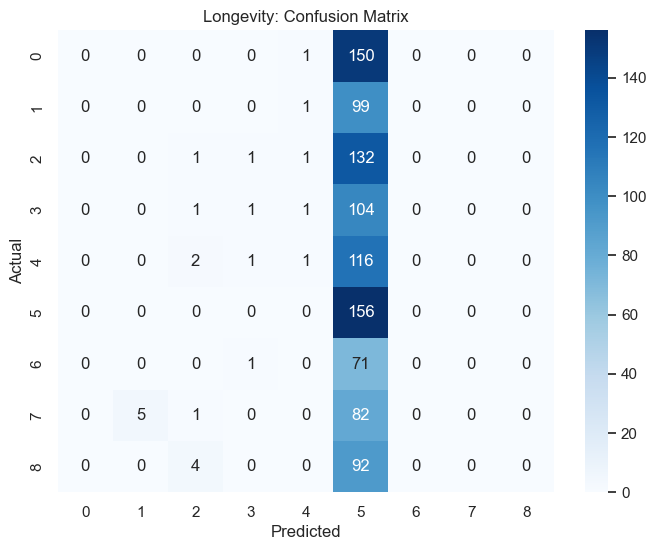

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_longevity, longevity_preds)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax)
ax.set_title("Longevity: Confusion Matrix")
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
plt.show()

In [32]:
summary_md = f"""
### Longevity model summary

- Model used: Random Forest.
- Accuracy: {accuracy_score(y_longevity, longevity_preds):.6f}
- Macro F1: {f1_score(y_longevity, longevity_preds, average="macro"):.6f}
- Weighted F1: {f1_score(y_longevity, longevity_preds, average="weighted"):.6f}
- Features aligned to `longevity_model.feature_names_in_`.
"""

print(summary_md)


### Longevity model summary

- Model used: Random Forest.
- Accuracy: 0.155122
- Macro F1: 0.035260
- Weighted F1: 0.046589
- Features aligned to `longevity_model.feature_names_in_`.



### Evaluation interpretation

The Random Forest longevity model now runs successfully after aligning the evaluation inputs with the model's expected features. However, the current evaluation remains weak, with low classification performance, which suggests that the target encoding, feature construction, or train/evaluation consistency still needs review.

This section is intentionally kept in the `model_evaluation.ipynb` notebook to document the final evaluation process after the earlier supervised-learning mismatch was corrected.